In [32]:
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
demand_history_raw_data = pd.read_parquet('../data/synthetic/demand_history.parquet')
demand_history_raw_data.head(10)

,date,destination_id,demand,day_of_week,is_weekend,promo_flag
0,2025-01-01,D01,48.87,2,False,0
1,2025-01-02,D01,43.73,3,False,0
2,2025-01-03,D01,47.48,4,False,0
3,2025-01-04,D01,41.60,5,True,0
4,2025-01-05,D01,46.25,6,True,1
5,2025-01-06,D01,44.57,0,False,0
6,2025-01-07,D01,40.87,1,False,0
7,2025-01-08,D01,58.83,2,False,1
8,2025-01-09,D01,48.30,3,False,0
9,2025-01-10,D01,46.24,4,False,0


In [34]:
destination = 'D01'

In [35]:
d1_demand_history = demand_history_raw_data[demand_history_raw_data['destination_id'] == destination]
d1_demand_history

,date,destination_id,demand,day_of_week,is_weekend,promo_flag
0,2025-01-01,D01,48.87,2,False,0
1,2025-01-02,D01,43.73,3,False,0
2,2025-01-03,D01,47.48,4,False,0
3,2025-01-04,D01,41.60,5,True,0
4,2025-01-05,D01,46.25,6,True,1
...,...,...,...,...,...,...
176,2025-06-26,D01,55.31,3,False,0
177,2025-06-27,D01,55.88,4,False,0
178,2025-06-28,D01,63.90,5,True,1
179,2025-06-29,D01,43.33,6,True,0


In [36]:
type(d1_demand_history)

pandas.DataFrame

In [37]:
import polars as pl
moving_average_df = d1_demand_history[["date", "destination_id", "demand"]].sort_values("date")
polars_moving_average = pl.from_pandas(moving_average_df)

In [38]:
from forecasting.models.rolling_window_forecaster import RollingWindowForecaster

forecaster = RollingWindowForecaster(rolling_window= 7)

moving_average_df = forecaster.predict(polars_moving_average)
moving_average_df.head(10)

date,destination_id,demand,ma_7_forecast
date,str,f64,f64
2025-01-01,"""D01""",48.87,null
2025-01-02,"""D01""",43.73,null
2025-01-03,"""D01""",47.48,null
2025-01-04,"""D01""",41.6,null
2025-01-05,"""D01""",46.25,null
2025-01-06,"""D01""",44.57,null
2025-01-07,"""D01""",40.87,null
2025-01-08,"""D01""",58.83,44.767143
2025-01-09,"""D01""",48.3,46.19


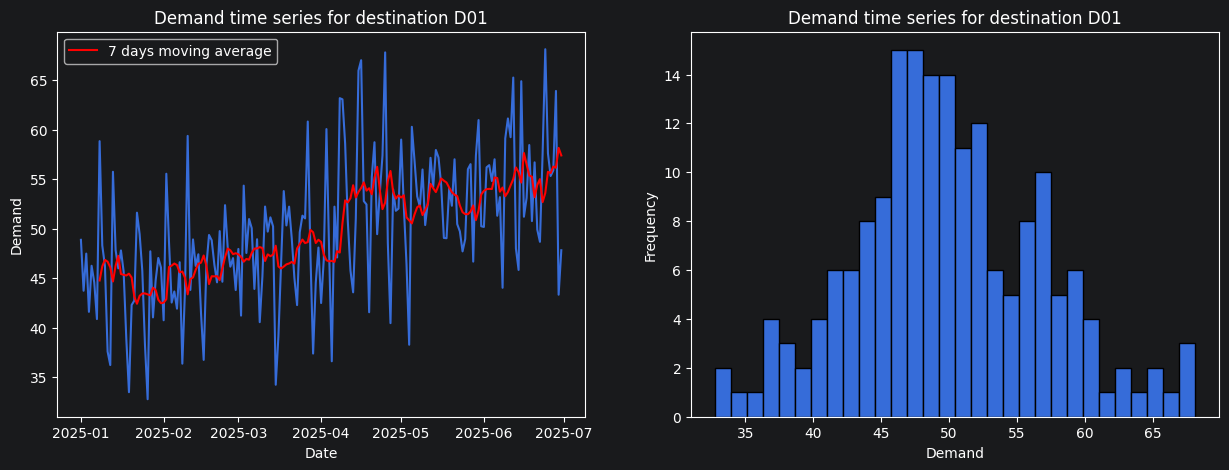

In [39]:
fig, (plot_ax, hist_ax) = plt.subplots(1, 2, figsize=(15, 5))

plot_ax.plot(d1_demand_history['date'], d1_demand_history['demand'])
plot_ax.set_xlabel("Date")
plot_ax.set_ylabel("Demand")
plot_ax.set_title(f'Demand time series for destination {destination}')

hist_ax.hist( d1_demand_history['demand'], bins = 30, edgecolor = 'black')
hist_ax.set_xlabel("Demand")
hist_ax.set_ylabel("Frequency")
hist_ax.set_title(f'Demand time series for destination {destination}')

plot_ax.plot(
    moving_average_df["date"],
    moving_average_df["ma_7_forecast"],
    color = 'red',
    label = '7 days moving average'
             )

plot_ax.legend()

plt.show()

In [40]:
from sklearn.metrics import mean_squared_error
import numpy as np
# I want to compute mean squared error
df_eval = moving_average_df.drop_nulls()

mse = mean_squared_error(df_eval['demand'], df_eval['ma_7_forecast'])
print("Mean squared error: %f" % mse)


Mean squared error: 40.254470
